In [1]:
#!pip install google.Generativeai
import os
import io
import google.generativeai as genai
from IPython.display import Markdown, display, update_display
import gradio as gr
from dotenv import load_dotenv
import subprocess

In [2]:
load_dotenv()
api_key = os.getenv("GEM_API_KEY")
genai.configure(api_key=api_key)

In [3]:
system_message = """You are an expert C++ software engineer specializing in writing clean, high-performance, and modern C++ code. 
                    Your sole purpose is to convert Python code snippets into their high-level C++ equivalents."""

In [4]:
def user_prompt(python):
    user_message = """Rewrite this python code in c++ with the fastest possible implementation that produces identical output in the least time,
    respond only with c++ code. Remember all necessary c++ packages.\n\n"""
    user_message += python
    return user_message

In [11]:
def message(python):
    return[
      {"role":"user", "parts": system_message},
      {"role":"user","parts": user_prompt(python)}
    ]

In [6]:
def write(cpp):
    """
    Writes a cleaned C++ code snippet into a file named 'optimized.cpp'.
    
    The function removes surrounding code block markers ('''cpp and ''') 
    from the given string and saves the resulting code into a file.

    Args:
        cpp (str): A string containing C++ code, possibly wrapped with '''cpp ... ''' markers.

    Returns:
        None
    """
    code = cpp.replace("'''cpp","").replace("'''","")
    with open("optimized.cpp","w") as f:
        f.write(code)

In [12]:
def optimize_gemini(python):
     """
    Optimizes a given Python code snippet using the Gemini model 
    and writes the optimized output to a file.

    The function sends the provided Python code to the Gemini 
    generative model for optimization. The response is streamed 
    in chunks, printed in real-time to the console, and the 
    complete optimized code is saved using the `write()` function.

    Args:
        python (str): A string containing Python source code to be optimized.

    Returns:
        None
    """
    model = genai.GenerativeModel("gemini-2.5-flash")
    response = model.generate_content(message(python), stream=True)

    reply = ""
    for chunk in response:
        fragment = chunk.text or ""
        reply += fragment
        print(fragment, end='', flush=True)

    write(reply)

In [8]:
code = """
n=5
fact = 1
for i in range(1,n+1):
    fact*=i
print(fact)
"""

In [9]:
exec(code)

120


In [13]:
optimize_gemini(code)

```cpp
#include <iostream>

int main() {
    // For competitive programming or performance-critical applications,
    // these lines can optimize I/O operations by decoupling C++ streams
/O library and un-tying cin from cout.
    // However, for this specific problem (single print), their impact is negligible.
    // std::ios_base::sync_with_stdio(false);
// std::cin.tie(NULL);

    int n = 5;
    // Use long long for 'fact' to safely store larger factorial values.
 but long long is safer for slightly larger inputs.
    long long fact = 1;

    // The loop iterates from 1 up to n (inclusive), calculating the factorial.
; ++i) {(int i = 1; i <= n
        fact *= i;
    }

    std::cout << fact << std::endl;

    return 0; // Indicate successful program execution
}
```

In [14]:
code_1 = """
def lengthOfLongestSubstring(s: str) -> int:
    char_set = set()
    left = 0
    max_length = 0
    
    for right in range(len(s)):
        while s[right] in char_set:
            char_set.remove(s[left])
            left += 1
        char_set.add(s[right])
        max_length = max(max_length, right - left + 1)
    
    return max_length
    """

In [15]:
optimize_gemini(code_1)

```cpp
#include <string>
#include <algorithm> // For std::max
#include <vector>    // For std::vector

int lengthOfLongestSubstring(std::string s) {
vector<int> char_map(256, -1); 
    
    int left = 0;
    int max_length = 0;
    
 right < s.length(); ++right) {
        int current_char_code = static_cast<unsigned char>(s[right]);
        
1 && char_map[current_char_code] >= left) {-
            left = char_map[current_char_code] + 1;
        }
        
_code] = right;p[current_char
        
        max_length = std::max(max_length, right - left + 1);
    }
    
    return max_length;
}

```

In [30]:
def stream_gemini(python):
    """
    Stream the response generated by the Gemini model for a given Python code input.

    This function uses the Gemini generative model (`gemini-2.5-flash`) to process
    the provided Python code and streams back the generated content in real-time.
    It yields partial responses as they arrive, followed by a final cleaned version
    where unnecessary code block markers (```cpp ... ```) are removed.

    Args:
        python (str): The Python code or prompt to send to the Gemini model.

    Yields:
        str: The progressively streamed response text, with the last yield containing
             the fully accumulated and cleaned response.
    """
    model = genai.GenerativeModel("gemini-2.5-flash")
    response = model.generate_content(message(python), stream=True)

    reply = ""
    for chunk in response:
        fragment = chunk.text or ""
        reply += fragment
        yield reply  
    
    yield reply.replace('```cpp\n','').replace('```','')


In [31]:
def optimize(python,model):
    """
    Optimize and stream the output for the given Python code using the specified model.

    This function delegates the input Python code to the appropriate model handler.
    Currently, it supports only the "gemini" model, which streams responses using
    the `stream_gemini` function. It yields the streamed response progressively.

    Args:
        python (str): The Python code or input prompt to be processed.
        model (str): The model to use for optimization. 
                     Supported value: "gemini".

    Yields:
        str: The progressively streamed response text from the selected model.

    Raises:
        ValueError: If the provided model is not supported.
    """
    if model == "gemini":
        result = stream_gemini(python)
    else:
        raise ValueError("Unknown Model")
    for stream_ in result:
        yield stream_

In [29]:
with gr.Blocks() as ui:
    with gr.Row():
        python = gr.Textbox(label="Python Code:", lines=10)
        cpp = gr.Textbox(label="C++ Code:", lines=10)
    with gr.Row():
        model = gr.Dropdown(["gemini"],label="model",value="gemini")
        convert = gr.Button("Convert Code")

    convert.click(optimize, inputs=[python,model],outputs=[cpp])
ui.launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


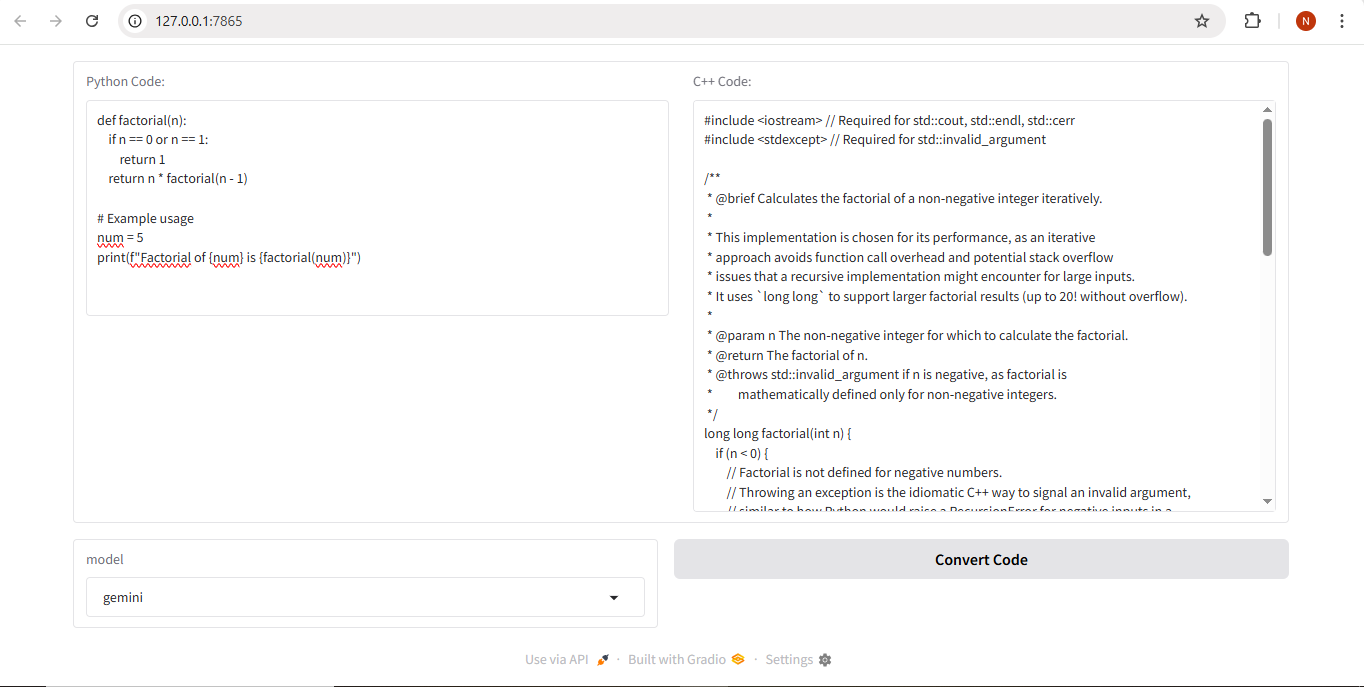

In [32]:
from IPython.display import Image

Image(filename="Pictures/Gradio.png")
